# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Malgun Gothic']
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.unicode_minus'] = False

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


**1. 데이터 로드 및 구조 확인**

In [4]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.head())   

(6000, 13)
customer_id            int64
age                    int64
gender                object
signup_channel        object
membership_tier       object
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group        object
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.

> 고객은 총 6000명이다. 고객의 나이는 18~78세, 월 방문 횟수는 1~34회, 평균 적용 할인율은 0~0.5 사이에 분포한다.

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

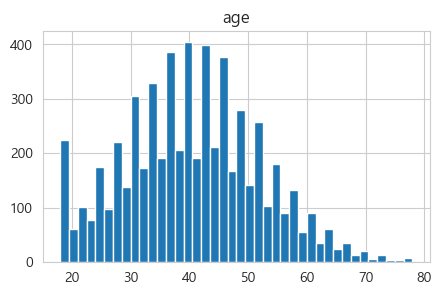

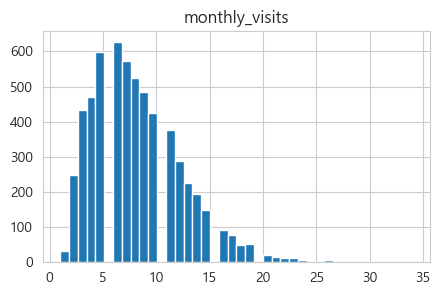

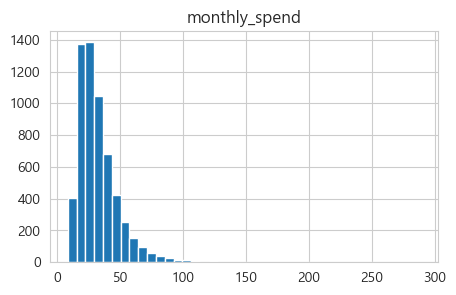

왜도 = 2.5456526289788064


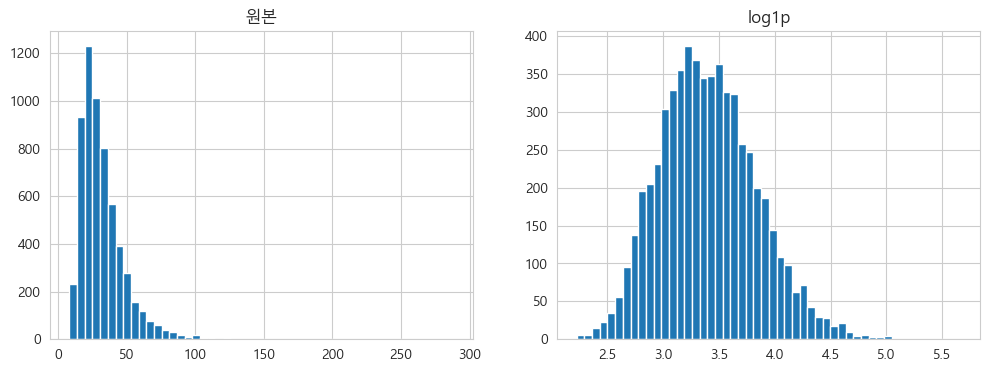

In [5]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.

> 대부분의 고객은 낮은 매출을 기록하고 소수의 고객만 높은 매출을 기록하고 있으므로 매출 분포가 치우치게 된다. 2.55에 달하는 왜도를 통해서도 분포가 크게 치우쳐져 있음을 알 수 있다. 또한 로그변환을 수행하면 분포가 대칭적으로 변화하여 정규 분포에 가까워지므로 이후 분석에 활용하기 용이하다.

**3. 채널·등급별 매출 Boxplot**

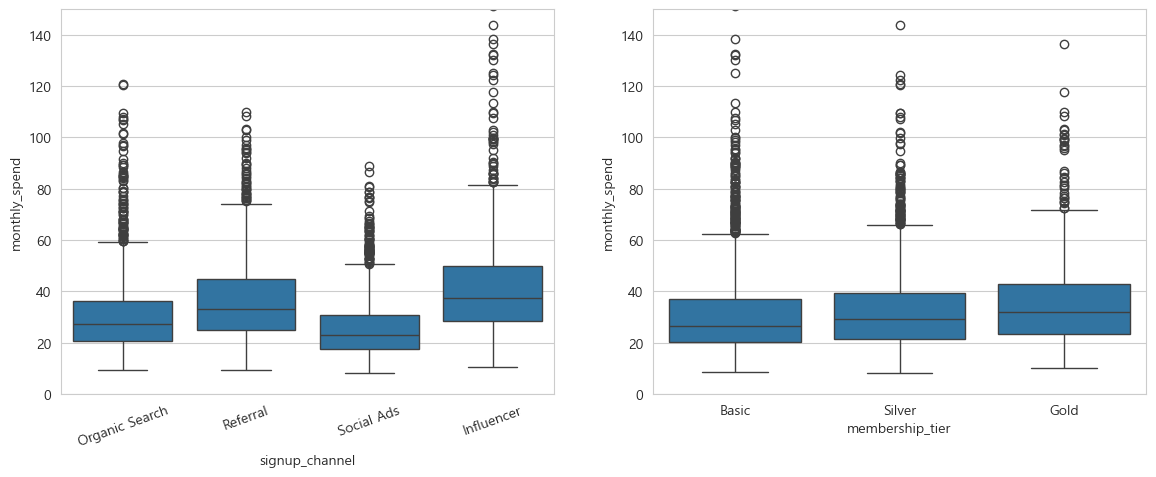

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.

> 그래프에 따르면 인플루언서 채널과 골드 등급이 고가치 고객에 해당한다.

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

> 1종 오류는 쿠폰 캠페인은 효과가 없지만 쿠폰 캠페인이 효과가 있다고 생각하는 것이다. 이렇게 되면 쿠폰 캠페인을 진행하는 데에 예산을 낭비하는 손실이 발생한다. 2종 오류는 쿠폰 캠페인은 효과가 있지만 쿠폰 캠페인이 효과가 없다고 생각하는 것이다. 이렇게 되면 쿠폰 캠페인으로 얻을 수 있었던 유익을 얻지 못하는 손실이 발생한다.

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

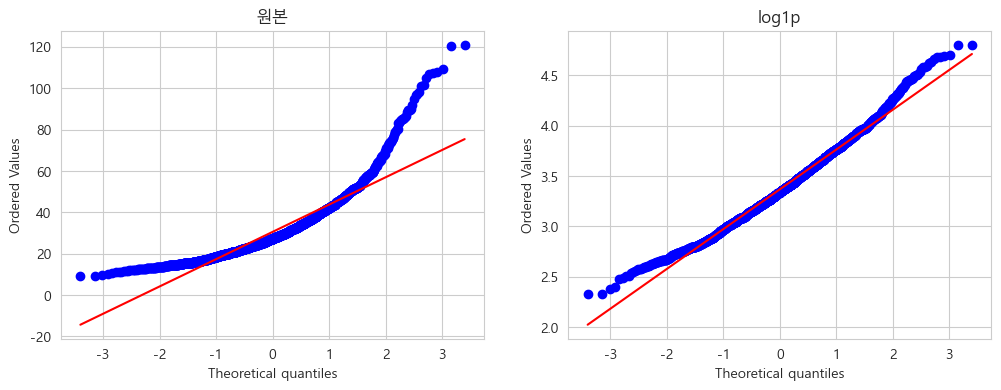

원본   ShapiroResult(statistic=np.float64(0.8534533976380867), pvalue=np.float64(3.631642400263992e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962407), pvalue=np.float64(0.00024486116128267225))


In [7]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.

> 정규성 검정의 귀무가설은 '데이터는 정규 분포를 따른다'이고, 대립가설은 '데이터는 정규 분포를 따르지 않는다'이다. P-value가 0.05 이상이면 귀무가설을 기각하지 못하고, 0.05 미만이면 귀무가설을 기각한다. 따라서 위의 정규성 검정 결과에 따르면 원본데이터와 로그 변환한 데이터 모두 정규 분포를 따르지 않는다. 비록 두 데이터 모두 정규성 검정은 통과하지 못했지만, 그래프를 보면 로그 변환한 데이터가 원본 데이터보다 정규성이 크게 개선된 것을 알 수 있다.

**6. 등분산성 검정**

In [8]:
groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248200273e-44


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

> 등분산성 검정의 귀무가설은 '각 집단의 분산은 동일하다'이고, 대립가설은 '각 집단의 분산은 동일하지 않다'이다. 위의 등분산성 검정 결과에 따르면 p값이 0.05보다 작으므로 데이터는 등분산성을 만족하지 않는다. 이는 한 그룹이 다른 그룹을 방해한다는 뜻이므로 Welch's ANOVA와 같은 대체적인 방법을 활용해야 한다.

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [9]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var=False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.164492092129461e-19
t=-11.88 p=3.86e-32


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

> H0는 '쿠퐁 발송군과 미발송군의 평균이 같다'이다. H1은 '쿠폰 발송군과 미발송군의 평균이 다르다'이다. Welch's t-test의 결과에 따르면 p값이 0.05보다 작으므로 두 집단의 평균이 다르다는 것을 알 수 있다. 또한 쿠폰 발송군이 미발송군보다 평균이 높음을 알 수 있다. 따라서 캠페인을 지속해야 한다.

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [10]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.

> 귀무가설은 '모든 채널의 평균이 같다'이고, 대립가설은 '적어도 하나의 채널은 평균이 다르다'이다. ANOVA 결과에 따르면 p값이 0.05보다 작으므로 서로 다른 채널 간의 평균의 차이가 있음을 알 수 있다. 또한 Tukey HSD 결과에 따르면 Influencer의 채널이 고가치이고, Social Ads 채널이 저가치임을 알 수 있다.

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [11]:
model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

> 귀무가설은 '효과가 없다'이고, 대립가설은 '효과가 있다'이다. Two-way ANOVA 결과에 따르면 채널의 주효과, 캠페인의 주효과, 채널과 캠페인 간의 교호 작용이 모두 존재한다. 따라서 채널에 따라 그리고 캠페인에 따라 매출이 달라지고, 채널의 효과는 캠페인에 따라 달라지는 것을 알 수 있다.

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [12]:
# 단순
m1 = smf.ols('monthly_spend ~  monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


In [13]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(signup_channel) + C(gender)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Mon, 20 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        21:27:25   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

> 방문, 할인, 광고비 모두 매출을 증가시킨다. 할인 확대는 매출 증가에 좋은 전략이다. 채널의 계수는 Influencer가 기준 범주일 때 Organic Search가 -12.1854, Referral이 -5.8608, Social Ads가 -16.6992 이므로, Organic Search, Referral, Social Ads 모두 Influencer에 비해 매출을 감소시키는 것을 알 수 있다. 

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [14]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']] 
print(vif_table(X_bad))

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


c:\Users\erin3\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

> 첫번째 결과에서는 VIF 값이 무한대로 나왔다. 이는 total=online+offline 사이에 선형관계가 존재하므로 완전 다중공선성이 발생함을 의미한다. 반면 두번째 결과에서는 VIF 값이 1에 가깝게 나왔다. 이는 total이 제거됨으로써 다중공선성이 사라졌음을 의미한다. 

**12. 잔차 진단** (+ 로그변환 비교)

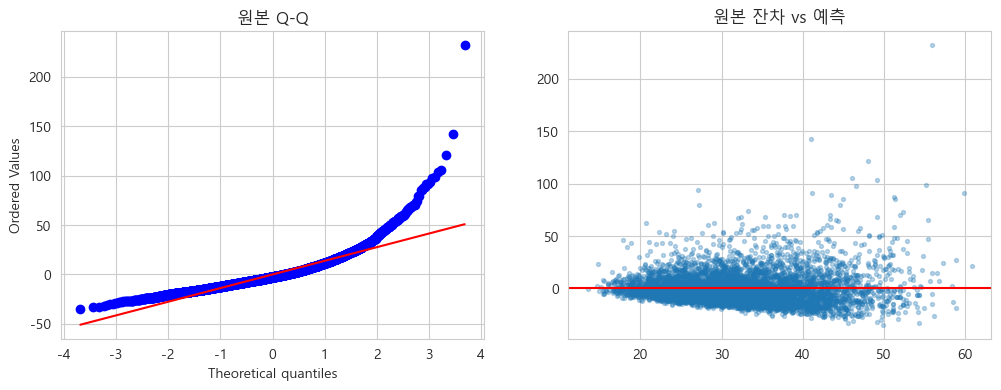

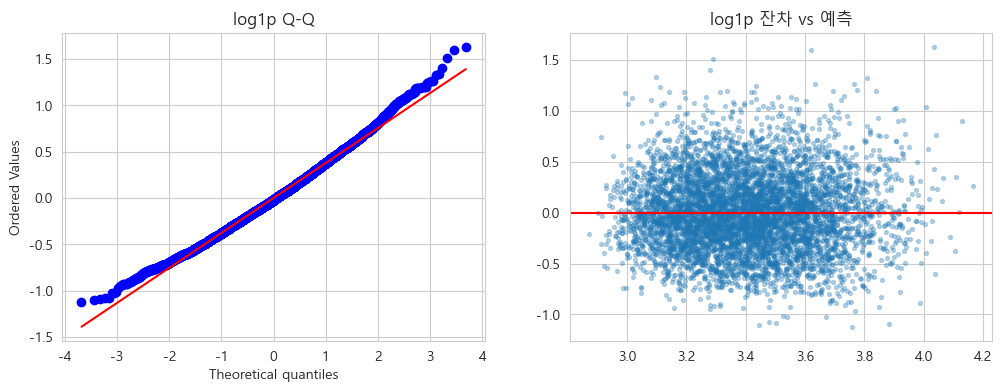

In [15]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

> Q-Q plot을 보면 원본 대비 로그변환 모형이 직선에 더 가까운 것을 알 수 있다. 이는 로그변환 후 정규성이 개선되었음을 의미한다. 또한 잔차의 분포를 나타내는 그래프를 보면 원본 대비 로그변환 모형의 분산이 더 일정한 것을 알 수 있다. 이는 로그변환 후 등분산성이 개선되었음을 의미한다. 정규성과 등분산성이 개선되면 정규성과 등분산성을 가정하는 여러 통계분석을 수행하기 수월해진다.

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [16]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Mon, 20 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        21:38:10   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

> 쿠폰 발송의 로지스틱 회귀 계수는 0.8895이다. 이는 쿠폰을 발송하면 반응할 오즈가 더 크다는 것을 의미한다. 또한 Gold 등급과 Silver 등급의 로지스틱 회귀 계수는 각각 0.7024, 0.3411이다. 이는 Basic 등급과 비교했을 때 Gold 등급과 Silver 등급이 반응할 오즈가 더 크다는 것을 의미한다. 특히 Gold 등급이 Silver 등급에 비해 반응할 오즈가 더 크다. 따라서 다음 캠페인은 골드 등급에게 쿠폰을 발송하는 방향으로 진행하는 것이 효과적이다. 

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)